# Лабораторная работа №2

In [107]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error,r2_score,  mean_absolute_percentage_error
import numpy as np
from scipy.stats import uniform, loguniform
from metrics import mse, rmse, mae, r_2, mape
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

In [108]:
data = pd.read_csv("data_sets/air.csv")
data.drop("Unnamed: 0", axis=1, inplace=True)
data

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,year,day,hour,month,day_of_week
0,0.21,0.51,0.23,0.41,0.12,0.49,0.51,0.46,0.33,0.50,0.28,0.00,0.30,0.78,3,3
1,0.16,0.46,0.18,0.35,0.07,0.40,0.45,0.33,0.33,0.48,0.26,0.00,0.30,0.83,3,3
2,0.18,0.54,0.17,0.34,0.09,0.50,0.45,0.37,0.30,0.56,0.28,0.00,0.30,0.87,3,3
3,0.18,0.52,0.17,0.35,0.12,0.53,0.46,0.43,0.28,0.64,0.29,0.00,0.30,0.91,3,3
4,0.13,0.45,0.12,0.28,0.09,0.51,0.42,0.39,0.28,0.63,0.30,0.00,0.30,0.96,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8870,0.25,0.48,0.26,0.44,0.34,0.84,0.37,0.66,0.51,0.25,0.28,1.00,0.10,0.43,4,1
8871,0.19,0.37,0.22,0.40,0.25,0.79,0.32,0.46,0.56,0.18,0.26,1.00,0.10,0.48,4,1
8872,0.19,0.36,0.24,0.42,0.21,0.77,0.31,0.38,0.62,0.11,0.22,1.00,0.10,0.52,4,1
8873,0.17,0.26,0.18,0.36,0.17,0.68,0.22,0.24,0.65,0.05,0.16,1.00,0.10,0.57,4,1


Для всех моделей в качестве таргета будем использовать `CO(GT)` - количество угарного газа в воздухе.

In [109]:
y = data["CO(GT)"]

In [110]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [111]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Scikit-learn", "Кастомные функции"],
    metrics
])

sklearn_and_custom_comparing = pd.DataFrame(columns=columns)
pd.options.display.float_format = '{:.3f}'.format
sklearn_and_custom_comparing

Empty DataFrame
Columns: [(Scikit-learn, R2), (Scikit-learn, MSE), (Scikit-learn, RMSE), (Scikit-learn, MAE), (Scikit-learn, MAPE), (Кастомные функции, R2), (Кастомные функции, MSE), (Кастомные функции, RMSE), (Кастомные функции, MAE), (Кастомные функции, MAPE)]
Index: []

In [112]:
def get_metrics_value(y_predict, y_test):
    sklearn_metrics = [r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error,
                       mean_absolute_percentage_error]
    custom_metrics = [r_2, mse, rmse, mae, mape]
    sklearn_metrics_results = []
    custom_metrics_results = []

    for sklearn_metric, custom_metric in zip(sklearn_metrics, custom_metrics):
        sklearn_metrics_results.append(sklearn_metric(y_test, y_predict))
        custom_metrics_results.append(custom_metric(y_test, y_predict))

    return sklearn_metrics_results, custom_metrics_results


In [113]:
def input_into_the_tables(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test,
                          sklearn_and_custom_comparing,
                          train_and_test_comparing):
    sk_learn_test_metrics, custom_test_metrics = get_metrics_value(predict_on_test_y, y_test)
    sklearn_and_custom_comparing.loc[name_of_model] = sk_learn_test_metrics + custom_test_metrics

    sk_learn_train_metrics, _ = get_metrics_value(predict_on_train_y, y_train)
    train_and_test_comparing.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics


### Простая линейная регрессия

Для построения модели простой линейной регрессии в качестве предикта будем использовать признак `PT08.S1(CO)` - показатели датчика S1 об уровне CO в воздухе.

In [114]:
X = data.drop("CO(GT)", axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_simple_train = X_train[["C6H6(GT)"]]
X_simple_test = X_test[["C6H6(GT)"]]

In [115]:
model = LinearRegression()
model.fit(X_simple_train, y_train)
simple_regression_predict_on_test_y = model.predict(X_simple_test)
simple_regression_predict_on_train_y = model.predict(X_simple_train)

Text(0.5, 1.0, 'Простая регрессия')

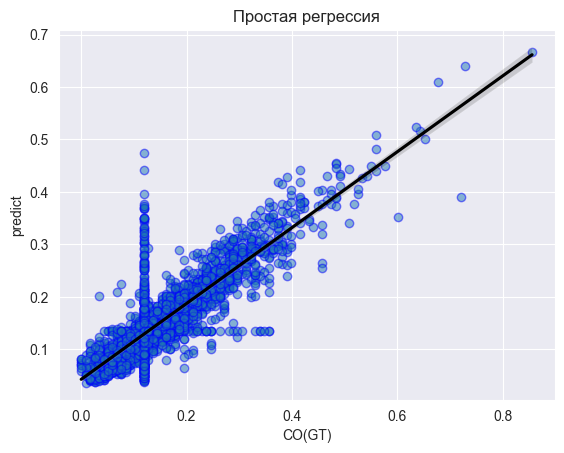

In [116]:
sns.regplot(y = simple_regression_predict_on_test_y, x = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.ylabel("predict")
plt.title("Простая регрессия")

In [117]:
input_into_the_tables("Linear regression",
                      simple_regression_predict_on_train_y, y_train,
                      simple_regression_predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [118]:
sklearn_and_custom_comparing.loc["Linear regression"]

Scikit-learn       R2                 0.729
                   MSE                0.003
                   RMSE               0.054
                   MAE                0.036
                   MAPE   1173507248505.247
Кастомные функции  R2                 0.729
                   MSE                0.003
                   RMSE               0.054
                   MAE                0.036
                   MAPE           26057.448
Name: Linear regression, dtype: float64

In [119]:
train_and_test_comparing.loc["Linear regression"]

Train Data  R2                 0.697
            MSE                0.003
            RMSE               0.056
            MAE                0.038
            MAPE   1415233432122.310
Test Data   R2                 0.729
            MSE                0.003
            RMSE               0.054
            MAE                0.036
            MAPE   1173507248505.247
Name: Linear regression, dtype: float64

#### Простая линейная регрессия с регуляризатором L1

Регуляризация с помощью Optuna

In [120]:
def lasso_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-10, 1e10, log=True)
    model = Lasso(alpha=alpha)
    model.fit(X_simple_train, y_train)
    y_pred = model.predict(X_simple_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [121]:
study = optuna.create_study(direction="minimize")
study.optimize(lasso_objective, n_trials=100)
best_params = study.best_params
best_params

[I 2026-03-04 20:03:15,947] A new study created in memory with name: no-name-219cea11-e55c-480d-8e36-67f862ad7063
[I 2026-03-04 20:03:15,951] Trial 0 finished with value: 0.0028703764120943274 and parameters: {'alpha': 3.0707235397845154e-10}. Best is trial 0 with value: 0.0028703764120943274.
[I 2026-03-04 20:03:15,954] Trial 1 finished with value: 0.010588330694338143 and parameters: {'alpha': 0.18301993305651235}. Best is trial 0 with value: 0.0028703764120943274.
[I 2026-03-04 20:03:15,957] Trial 2 finished with value: 0.010588330694338143 and parameters: {'alpha': 12826.407813854088}. Best is trial 0 with value: 0.0028703764120943274.
[I 2026-03-04 20:03:15,961] Trial 3 finished with value: 0.0028703797845601653 and parameters: {'alpha': 2.867889561187049e-07}. Best is trial 0 with value: 0.0028703764120943274.
[I 2026-03-04 20:03:15,964] Trial 4 finished with value: 0.010588330694338143 and parameters: {'alpha': 2188210738.869602}. Best is trial 0 with value: 0.002870376412094327

{'alpha': 1.0010625884211137e-10}

In [122]:
lasso_model = Lasso(alpha=best_params["alpha"])
lasso_model.fit(X_simple_train, y_train)

,alpha,1.0010625884211137e-10
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [123]:
l1_regression_predict_on_train_y = lasso_model.predict(X_simple_train)
l1_regression_predict_on_test_y = lasso_model.predict(X_simple_test)

In [124]:
input_into_the_tables("Linear regression with L1",
                      l1_regression_predict_on_train_y, y_train,
                      l1_regression_predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

Text(0.5, 1.0, 'Простая регрессия с L1 регуляризацией')

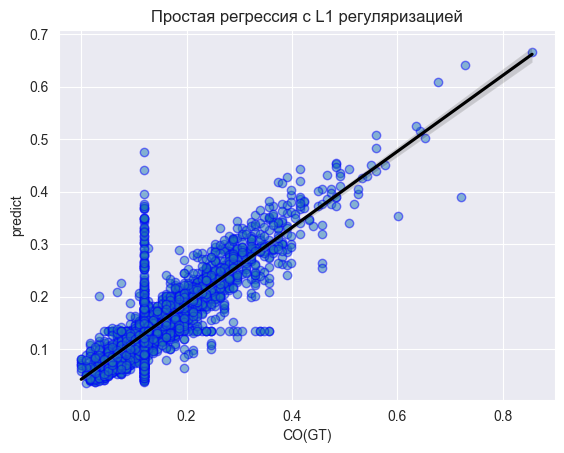

In [125]:
sns.regplot(y=l1_regression_predict_on_test_y, x = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.ylabel("predict")
plt.title("Простая регрессия с L1 регуляризацией")

Text(0.5, 1.0, 'Простая регрессия с L1 регуляризацией')

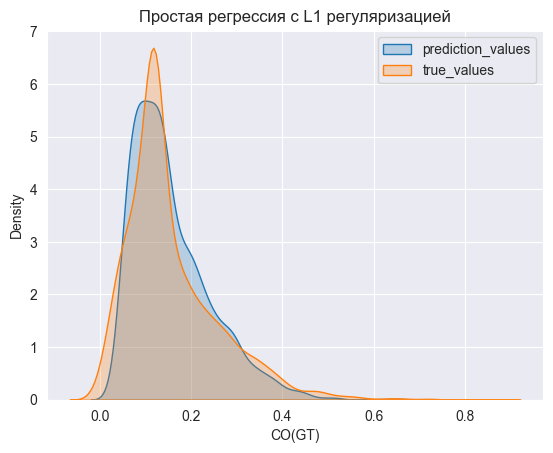

In [126]:
sns.kdeplot(l1_regression_predict_on_test_y, label="prediction_values", fill=True)
sns.kdeplot(y_test, label="true_values", fill=True)
plt.legend()
plt.title("Простая регрессия с L1 регуляризацией")

#### Простая линейная регрессия с регуляризатором L2

In [127]:
ridge_model = Ridge()
param_grid = {'alpha':np.logspace(-10, 10)}

randomize_search = RandomizedSearchCV(
    estimator = ridge_model,
    param_distributions = param_grid,
    scoring="neg_mean_squared_error"
)

randomize_search.fit(X_simple_train, y_train)
print(randomize_search.best_params_)

{'alpha': np.float64(6.551285568595495e-10)}


In [128]:
l2_regression_predict_on_train_y = randomize_search.predict(X_simple_train)
l2_regression_predict_on_test_y = randomize_search.predict(X_simple_test)

In [129]:
input_into_the_tables("Linear regression with L2",
                      l2_regression_predict_on_train_y, y_train,
                      l2_regression_predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

Text(0.5, 1.0, 'Простая регрессия с L2 регуляризацией')

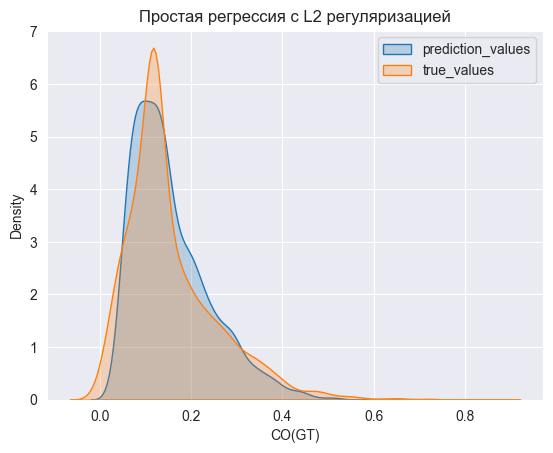

In [130]:
sns.kdeplot(l2_regression_predict_on_test_y, label="prediction_values", fill=True)
sns.kdeplot(y_test, label="true_values", fill=True)
plt.legend()
plt.title("Простая регрессия с L2 регуляризацией")

#### Простая линейная регрессия с ElasticNet

In [131]:
base_elastic_model = ElasticNet(max_iter=100000)
param_grid = {'alpha':np.logspace(-10, 10)}
grid_search = GridSearchCV(
    estimator=base_elastic_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
)
grid_search.fit(X_simple_train, y_train)
print(grid_search.best_params_)

{'alpha': np.float64(1e-10)}


In [132]:
elasticnet_regression_predict_on_train_y = grid_search.predict(X_simple_train)
elasticnet_regression_predict_on_test_y = grid_search.predict(X_simple_test)
input_into_the_tables("Linear regression with ElasticNet",
                      elasticnet_regression_predict_on_train_y, y_train,
                      elasticnet_regression_predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

Text(0.5, 1.0, 'Простая регрессия с ElasticNet регуляризацией')

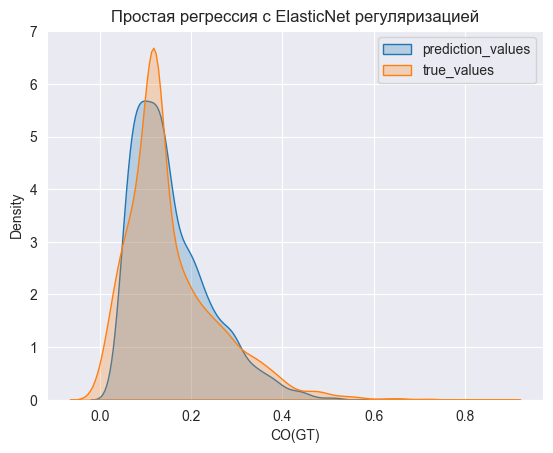

In [133]:
sns.kdeplot(elasticnet_regression_predict_on_test_y, label="prediction_values", fill=True)
sns.kdeplot(y_test, label="true_values", fill=True)
plt.legend()
plt.title("Простая регрессия с ElasticNet регуляризацией")

In [134]:
sklearn_and_custom_comparing

Scikit-learn                    \
                                            R2   MSE  RMSE   MAE   
Linear regression                        0.729 0.003 0.054 0.036   
Linear regression with L1                0.729 0.003 0.054 0.036   
Linear regression with L2                0.729 0.003 0.054 0.036   
Linear regression with ElasticNet        0.729 0.003 0.054 0.036   

                                                    Кастомные функции        \
                                               MAPE                R2   MSE   
Linear regression                 1173507248505.247             0.729 0.003   
Linear regression with L1         1173507260579.318             0.729 0.003   
Linear regression with L2         1173507248513.141             0.729 0.003   
Linear regression with ElasticNet 1173507258546.447             0.729 0.003   

                                                         
                                   RMSE   MAE      MAPE  
Linear regression                 0.054 0.036 26057.448  
Linear regression with L1         0.054 0.036 26057.448  
Linear regression with L2         0.054 0.036 26057.448  
Linear regression with ElasticNet 0.054 0.036 26057.448

In [135]:
train_and_test_comparing

Train Data                    \
                                          R2   MSE  RMSE   MAE   
Linear regression                      0.697 0.003 0.056 0.038   
Linear regression with L1              0.697 0.003 0.056 0.038   
Linear regression with L2              0.697 0.003 0.056 0.038   
Linear regression with ElasticNet      0.697 0.003 0.056 0.038   

                                                    Test Data              \
                                               MAPE        R2   MSE  RMSE   
Linear regression                 1415233432122.310     0.729 0.003 0.054   
Linear regression with L1         1415233442937.686     0.729 0.003 0.054   
Linear regression with L2         1415233432129.381     0.729 0.003 0.054   
Linear regression with ElasticNet 1415233441116.737     0.729 0.003 0.054   

                                                           
                                    MAE              MAPE  
Linear regression                 0.036 1173507248505.247  
Linear regression with L1         0.036 1173507260579.318  
Linear regression with L2         0.036 1173507248513.141  
Linear regression with ElasticNet 0.036 1173507258546.447

### Множественная линейная регрессия

In [136]:
model = LinearRegression()
model.fit(X_train, y_train)
multiple_reg_train_prediction = model.predict(X_train)
multiple_reg_test_prediction = model.predict(X_test)

input_into_the_tables("Multiple regression",
                      multiple_reg_train_prediction, y_train,
                      multiple_reg_test_prediction, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

<Axes: xlabel='CO(GT)'>

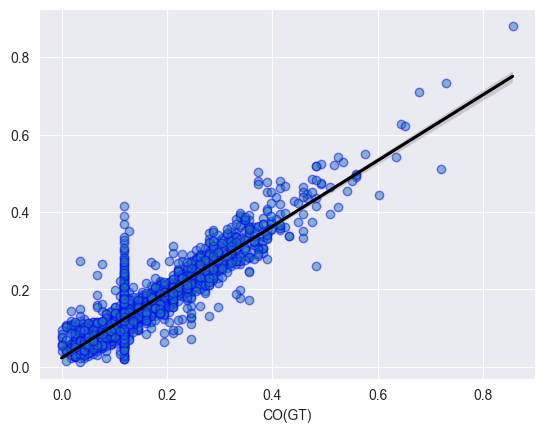

In [137]:
sns.regplot(y = multiple_reg_test_prediction, x = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})

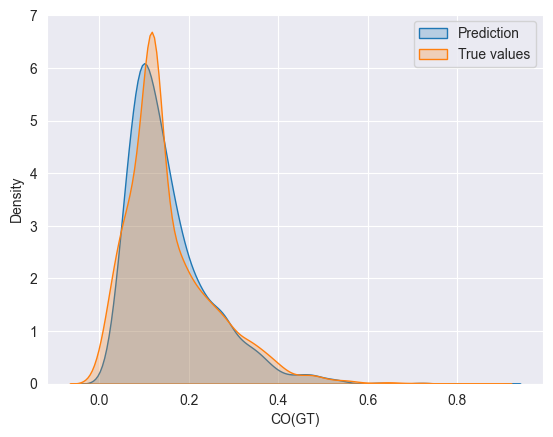

In [138]:
sns.kdeplot(x = multiple_reg_test_prediction, fill=True, label="Prediction")
sns.kdeplot(x = y_test, fill=True, label="True values")
plt.legend()

In [139]:
train_and_test_comparing.loc[["Linear regression", "Multiple regression"]]

Train Data                                     Test Data  \
                            R2   MSE  RMSE   MAE              MAPE        R2   
Linear regression        0.697 0.003 0.056 0.038 1415233432122.310     0.729   
Multiple regression      0.831 0.002 0.042 0.029 1422645320679.430     0.838   

                                                         
                      MSE  RMSE   MAE              MAPE  
Linear regression   0.003 0.054 0.036 1173507248505.247  
Multiple regression 0.002 0.041 0.028 1100029070040.305

### Множественная линейная регрессия c L1 регуляризацией

In [140]:
def lasso_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-10, 1e10, log=True)
    model = Lasso(alpha=alpha)
    model.fit(X_simple_train, y_train)
    y_pred = model.predict(X_simple_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [141]:
study = optuna.create_study(direction="minimize")
study.optimize(lasso_objective, n_trials=100)
best_params = study.best_params
best_params

[I 2026-03-04 20:03:19,447] A new study created in memory with name: no-name-b3176b53-a01d-4bb8-89c2-5dbfb3cf6941
[I 2026-03-04 20:03:19,451] Trial 0 finished with value: 0.010588330694338143 and parameters: {'alpha': 7671.252769696838}. Best is trial 0 with value: 0.010588330694338143.
[I 2026-03-04 20:03:19,454] Trial 1 finished with value: 0.010588330694338143 and parameters: {'alpha': 2924298638.7199793}. Best is trial 0 with value: 0.010588330694338143.
[I 2026-03-04 20:03:19,457] Trial 2 finished with value: 0.004518806669171331 and parameters: {'alpha': 0.0050043225695426494}. Best is trial 2 with value: 0.004518806669171331.
[I 2026-03-04 20:03:19,460] Trial 3 finished with value: 0.002870509141226846 and parameters: {'alpha': 1.0677124019638346e-05}. Best is trial 3 with value: 0.002870509141226846.
[I 2026-03-04 20:03:19,463] Trial 4 finished with value: 0.010588330694338143 and parameters: {'alpha': 18617025.57704091}. Best is trial 3 with value: 0.002870509141226846.
[I 202

{'alpha': 1.0023558662988416e-10}

In [142]:
l1_multiple_reg = Lasso(alpha=best_params["alpha"])
l1_multiple_reg.fit(X_train, y_train)

l1_multiple_reg_train_prediction = model.predict(X_train)
l1_multiple_reg_test_prediction = model.predict(X_test)

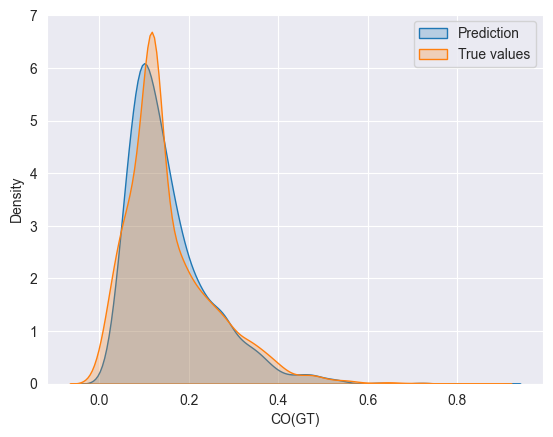

In [143]:
sns.kdeplot(x = l1_multiple_reg_test_prediction, fill=True, label="Prediction")
sns.kdeplot(x = y_test, fill=True, label="True values")
plt.legend()

In [144]:
input_into_the_tables("L1-Multiple regression",
                      l1_multiple_reg_train_prediction, y_train,
                      l1_multiple_reg_test_prediction, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [145]:
train_and_test_comparing.loc[["Linear regression", "Multiple regression", "L1-Multiple regression"]]

Train Data                                      \
                               R2   MSE  RMSE   MAE              MAPE   
Linear regression           0.697 0.003 0.056 0.038 1415233432122.310   
Multiple regression         0.831 0.002 0.042 0.029 1422645320679.430   
L1-Multiple regression      0.831 0.002 0.042 0.029 1422645320679.430   

                       Test Data                                      
                              R2   MSE  RMSE   MAE              MAPE  
Linear regression          0.729 0.003 0.054 0.036 1173507248505.247  
Multiple regression        0.838 0.002 0.041 0.028 1100029070040.305  
L1-Multiple regression     0.838 0.002 0.041 0.028 1100029070040.305

### Множественная линейная регрессия c L2 регуляризацией

In [146]:
ridge_model = Ridge()
param_grid = {'alpha':np.logspace(-10, 10)}

l2_multiple_search = GridSearchCV(
    estimator = ridge_model,
    param_grid = param_grid,
    scoring="neg_mean_squared_error"
)

l2_multiple_search.fit(X_train, y_train)
print(l2_multiple_search.best_params_)

{'alpha': np.float64(1e-10)}


In [147]:
l2multiple_reg_train_prediction = l2_multiple_search.predict(X_train)
l2multiple_reg_test_prediction = l2_multiple_search.predict(X_test)

input_into_the_tables("L2-Multiple regression",
                      l2multiple_reg_train_prediction, y_train,
                      l2multiple_reg_test_prediction, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [148]:
train_and_test_comparing.loc[["L1-Multiple regression", "L2-Multiple regression"]]

Train Data                                      \
                               R2   MSE  RMSE   MAE              MAPE   
L1-Multiple regression      0.831 0.002 0.042 0.029 1422645320679.430   
L2-Multiple regression      0.831 0.002 0.042 0.029 1422645320675.484   

                       Test Data                                      
                              R2   MSE  RMSE   MAE              MAPE  
L1-Multiple regression     0.838 0.002 0.041 0.028 1100029070040.305  
L2-Multiple regression     0.838 0.002 0.041 0.028 1100029070035.198

In [149]:
r2_score(y_true=y_test, y_pred=l2multiple_reg_test_prediction)

0.8379321638796832